In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import sqlite3
import statsmodels.api as sm
from scipy.stats import randint
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 1) Data Import and Preprocessing

### 1.1) General Preprocessing

In [3]:
# raw_train_data = pd.read_csv("../data/raw/cs-training.csv")

# conn = sqlite3.connect("../data/raw/credit_risk.db")

# raw_train_data.to_sql(
#     "credit_risk_train",
#     conn,
#     if_exists="replace",
#     index=False
# )

In [4]:
conn = sqlite3.connect("../data/raw/credit_risk.db")

raw_train_data = pd.read_sql_query(
    "SELECT * FROM credit_risk_train",
    conn
)

In [5]:
raw_train_data.shape

(150000, 12)

In [6]:
raw_train_data.head(3)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [7]:
raw_train_data.columns = raw_train_data.columns.str.lower()

In [8]:
raw_train_data.drop(["unnamed: 0"], axis=1, inplace=True)

In [9]:
raw_train_data.columns

Index(['seriousdlqin2yrs', 'revolvingutilizationofunsecuredlines', 'age',
       'numberoftime30-59dayspastduenotworse', 'debtratio', 'monthlyincome',
       'numberofopencreditlinesandloans', 'numberoftimes90dayslate',
       'numberrealestateloansorlines', 'numberoftime60-89dayspastduenotworse',
       'numberofdependents'],
      dtype='str')

In [10]:
raw_train_data["acct_id"] = "id_" + pd.Series(range(1, len(raw_train_data)+1)).astype(str)

In [11]:
raw_train_data.rename(columns = {
    "seriousdlqin2yrs" : "f_dpd_90plus_nxt_2yrs",
    "revolvingutilizationofunsecuredlines" : "avg_utli_unsec",
    "numberoftime30-59dayspastduenotworse" : "n_dpd_30_50_l2yrs",
    "debtratio" : "debt_income_ratio",
    "monthlyincome" : "monthly_income",
    "numberofopencreditlinesandloans" : "n_credit_lines",
    "numberoftimes90dayslate" : "n_dpd_90plus_hist",
    "numberrealestateloansorlines" : "n_mort_loans",
    "numberoftime60-89dayspastduenotworse" : "n_dpd_60_89_l2yrs",
    "numberofdependents" : "n_dependents"
    }, inplace=True
)

In [12]:
raw_train_data.dtypes

f_dpd_90plus_nxt_2yrs      int64
avg_utli_unsec           float64
age                        int64
n_dpd_30_50_l2yrs          int64
debt_income_ratio        float64
monthly_income           float64
n_credit_lines             int64
n_dpd_90plus_hist          int64
n_mort_loans               int64
n_dpd_60_89_l2yrs          int64
n_dependents             float64
acct_id                      str
dtype: object

In [13]:
raw_train_data.columns

Index(['f_dpd_90plus_nxt_2yrs', 'avg_utli_unsec', 'age', 'n_dpd_30_50_l2yrs',
       'debt_income_ratio', 'monthly_income', 'n_credit_lines',
       'n_dpd_90plus_hist', 'n_mort_loans', 'n_dpd_60_89_l2yrs',
       'n_dependents', 'acct_id'],
      dtype='str')

In [14]:
raw_train_data = raw_train_data[
    ["acct_id", "n_dpd_90plus_hist", "n_dpd_60_89_l2yrs", "n_dpd_30_50_l2yrs", "n_mort_loans", "n_credit_lines",
     "n_dependents", "avg_utli_unsec", "debt_income_ratio", "monthly_income", "age", "f_dpd_90plus_nxt_2yrs"]
]

In [15]:
raw_train_data.head(3)

,acct_id,n_dpd_90plus_hist,n_dpd_60_89_l2yrs,n_dpd_30_50_l2yrs,n_mort_loans,n_credit_lines,n_dependents,avg_utli_unsec,debt_income_ratio,monthly_income,age,f_dpd_90plus_nxt_2yrs
0,id_1,0,0,2,6,13,2.0,0.766127,0.802982,9120.0,45,1
1,id_2,0,0,0,0,4,1.0,0.957151,0.121876,2600.0,40,0
2,id_3,1,0,1,0,2,0.0,0.658180,0.085113,3042.0,38,0


### 1.2) Handling Missing Values - Median Imputation + Missing Column Indicator Method

In [16]:
raw_train_data.head(10)

,acct_id,n_dpd_90plus_hist,n_dpd_60_89_l2yrs,n_dpd_30_50_l2yrs,n_mort_loans,n_credit_lines,n_dependents,avg_utli_unsec,debt_income_ratio,monthly_income,age,f_dpd_90plus_nxt_2yrs
0,id_1,0,0,2,6,13,2.0,0.766127,0.802982,9120.0,45,1
1,id_2,0,0,0,0,4,1.0,0.957151,0.121876,2600.0,40,0
2,id_3,1,0,1,0,2,0.0,0.658180,0.085113,3042.0,38,0
3,id_4,0,0,0,0,5,0.0,0.233810,0.036050,3300.0,30,0
4,id_5,0,0,1,1,7,0.0,0.907239,0.024926,63588.0,49,0
5,id_6,0,0,0,1,3,1.0,0.213179,0.375607,3500.0,74,0
6,id_7,0,0,0,3,8,0.0,0.305682,5710.000000,NaN,57,0
7,id_8,0,0,0,0,8,0.0,0.754464,0.209940,3500.0,39,0
8,id_9,0,0,0,0,2,NaN,0.116951,46.000000,NaN,27,0
9,id_10,0,0,0,4,9,2.0,0.189169,0.606291,23684.0,57,0


In [17]:
raw_train_data.isna().sum()

acct_id                      0
n_dpd_90plus_hist            0
n_dpd_60_89_l2yrs            0
n_dpd_30_50_l2yrs            0
n_mort_loans                 0
n_credit_lines               0
n_dependents              3924
avg_utli_unsec               0
debt_income_ratio            0
monthly_income           29731
age                          0
f_dpd_90plus_nxt_2yrs        0
dtype: int64

In [18]:
print("missing values in following vars:", "n_dependents,", "monthly_income")
print("% missing in n_dependents:", 100 * (raw_train_data["n_dependents"].isna().sum() / raw_train_data.shape[0]))
print("% missing in monthly_income:", 100 * (raw_train_data["monthly_income"].isna().sum() / raw_train_data.shape[0]))

missing values in following vars: n_dependents, monthly_income
% missing in n_dependents: 2.616
% missing in monthly_income: 19.820666666666668


In [19]:
print("mean for n_dependents:", raw_train_data["n_dependents"].mean())
print("mean for monthly_income:", raw_train_data["monthly_income"].mean())

mean for n_dependents: 0.7572222678605657
mean for monthly_income: 6670.221237392844


In [20]:
print("median for n_dependents:", raw_train_data["n_dependents"].median())
print("median for monthly_income:", raw_train_data["monthly_income"].median())

median for n_dependents: 0.0
median for monthly_income: 5400.0


In [21]:
raw_train_data = raw_train_data.assign(
    n_dependents_nan_flag = np.where(
        raw_train_data["n_dependents"].isna(), 1, 0
    ),
    monthly_income_nan_flag = np.where(
        raw_train_data["monthly_income"].isna(), 1, 0
    )
)

In [22]:
raw_train_data["n_dependents_imp"] = raw_train_data["n_dependents"].fillna(raw_train_data["n_dependents"].median())
raw_train_data["monthly_income_imp"] = raw_train_data["monthly_income"].fillna(raw_train_data["monthly_income"].median())

In [23]:
raw_train_data.drop(columns=["n_dependents", "monthly_income"], inplace=True)

In [24]:
raw_train_data.head(10)

,acct_id,n_dpd_90plus_hist,n_dpd_60_89_l2yrs,n_dpd_30_50_l2yrs,n_mort_loans,n_credit_lines,avg_utli_unsec,debt_income_ratio,age,f_dpd_90plus_nxt_2yrs,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp
0,id_1,0,0,2,6,13,0.766127,0.802982,45,1,0,0,2.0,9120.0
1,id_2,0,0,0,0,4,0.957151,0.121876,40,0,0,0,1.0,2600.0
2,id_3,1,0,1,0,2,0.658180,0.085113,38,0,0,0,0.0,3042.0
3,id_4,0,0,0,0,5,0.233810,0.036050,30,0,0,0,0.0,3300.0
4,id_5,0,0,1,1,7,0.907239,0.024926,49,0,0,0,0.0,63588.0
5,id_6,0,0,0,1,3,0.213179,0.375607,74,0,0,0,1.0,3500.0
6,id_7,0,0,0,3,8,0.305682,5710.000000,57,0,0,1,0.0,5400.0
7,id_8,0,0,0,0,8,0.754464,0.209940,39,0,0,0,0.0,3500.0
8,id_9,0,0,0,0,2,0.116951,46.000000,27,0,1,1,0.0,5400.0
9,id_10,0,0,0,4,9,0.189169,0.606291,57,0,0,0,2.0,23684.0


## 2) Univariate Data Analysis

In [25]:
raw_train_data.columns

Index(['acct_id', 'n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs',
       'n_dpd_30_50_l2yrs', 'n_mort_loans', 'n_credit_lines', 'avg_utli_unsec',
       'debt_income_ratio', 'age', 'f_dpd_90plus_nxt_2yrs',
       'n_dependents_nan_flag', 'monthly_income_nan_flag', 'n_dependents_imp',
       'monthly_income_imp'],
      dtype='str')

In [26]:
train_data = raw_train_data.copy(deep=True)

f_dpd_90plus_nxt_2yrs
0    139974
1     10026
Name: count, dtype: int64



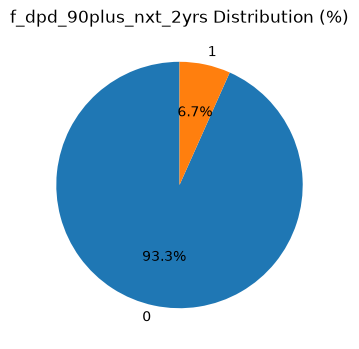

In [27]:
#f_dpd_90plus_nxt_2yrs - response variable
print(train_data["f_dpd_90plus_nxt_2yrs"].value_counts())
print()

uniq_cnts = train_data["f_dpd_90plus_nxt_2yrs"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
plt.figure(figsize=(4,4))
plt.pie(
    uniq_cnts.values,
    labels=uniq_cnts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("f_dpd_90plus_nxt_2yrs Distribution (%)")
plt.show()

In [29]:
#n_dependents_imp & n_dependents_nan_flag
uniq_cnts_1 = train_data["n_dependents_imp"].value_counts(normalize=True) * 100
uniq_cnts_1 = uniq_cnts_1.sort_values(ascending=False)
print(uniq_cnts_1)
print()
uniq_cnts_2 = train_data["n_dependents_nan_flag"].value_counts(normalize=True) * 100
uniq_cnts_2 = uniq_cnts_2.sort_values(ascending=False)
print(uniq_cnts_2)

n_dependents_imp
0.0     60.550667
1.0     17.544000
2.0     13.014667
3.0      6.322000
4.0      1.908000
5.0      0.497333
6.0      0.105333
7.0      0.034000
8.0      0.016000
10.0     0.003333
9.0      0.003333
20.0     0.000667
13.0     0.000667
Name: proportion, dtype: float64

n_dependents_nan_flag
0    97.384
1     2.616
Name: proportion, dtype: float64


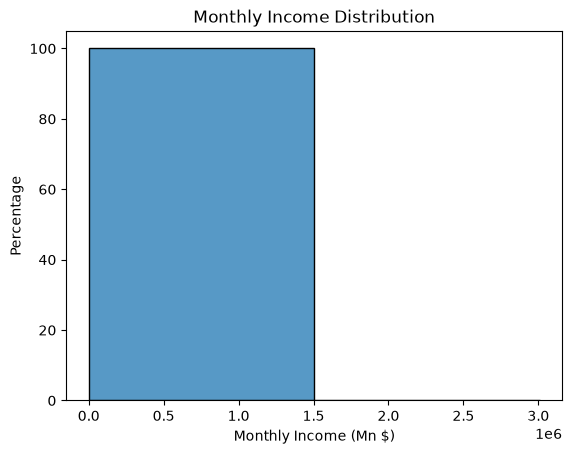

In [30]:
#monthly_income_imp & monthly_income_nan_flag
sns.histplot(train_data["monthly_income_imp"], bins=2, stat="percent")
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income (Mn $)")
plt.ylabel("Percentage")
plt.show()

In [31]:
#monthly_income_imp & monthly_income_nan_flag
print("min_monthly_income:", train_data["monthly_income_imp"].min(), "max_monthly_income:", train_data["monthly_income_imp"].max())
print()
uniq_cnts_1 = train_data["monthly_income_imp"].value_counts(normalize=True) * 100
uniq_cnts_1 = uniq_cnts_1.sort_values(ascending=False)
print(uniq_cnts_1)
print()
uniq_cnts_2 = train_data["monthly_income_nan_flag"].value_counts(normalize=True) * 100
uniq_cnts_2 = uniq_cnts_2.sort_values(ascending=False)
print(uniq_cnts_2)

min_monthly_income: 0.0 max_monthly_income: 3008750.0

monthly_income_imp
5400.0     20.041333
5000.0      1.838000
4000.0      1.404000
6000.0      1.289333
3000.0      1.172000
             ...    
7039.0      0.000667
596.0       0.000667
15648.0     0.000667
521.0       0.000667
7647.0      0.000667
Name: proportion, Length: 13594, dtype: float64

monthly_income_nan_flag
0    80.179333
1    19.820667
Name: proportion, dtype: float64


n_dpd_90plus_hist
0     94.441333
1      3.495333
2      1.036667
3      0.444667
4      0.194000
98     0.176000
5      0.087333
6      0.053333
7      0.025333
8      0.014000
9      0.012667
10     0.005333
96     0.003333
11     0.003333
13     0.002667
15     0.001333
14     0.001333
12     0.001333
17     0.000667
Name: proportion, dtype: float64



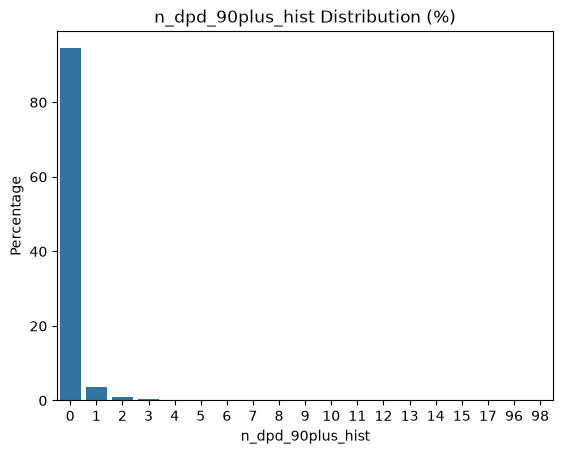

In [ ]:
uniq_cnts = train_data["n_dpd_90plus_hist"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)
print()
sns.barplot(x=uniq_cnts.index, y=uniq_cnts.values)
plt.ylabel("Percentage")
plt.title("n_dpd_90plus_hist Distribution (%)")
plt.show()

n_dpd_60_89_l2yrs
0     94.930667
1      3.820667
2      0.745333
3      0.212000
98     0.176000
4      0.070000
5      0.022667
6      0.010667
7      0.006000
96     0.003333
8      0.001333
11     0.000667
9      0.000667
Name: proportion, dtype: float64



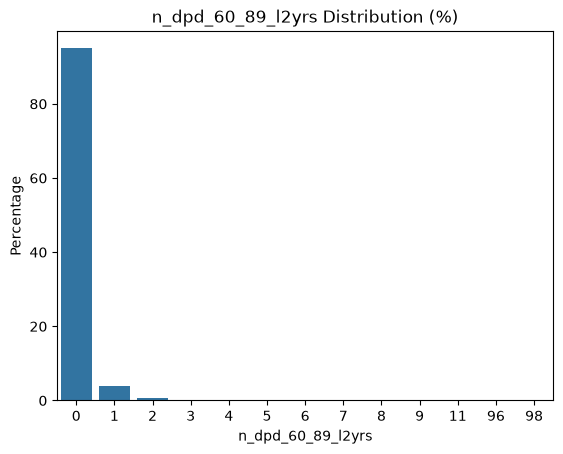

In [33]:
uniq_cnts = train_data["n_dpd_60_89_l2yrs"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)
print()
sns.barplot(x=uniq_cnts.index, y=uniq_cnts.values)
plt.ylabel("Percentage")
plt.title("n_dpd_60_89_l2yrs Distribution (%)")
plt.show()

n_dpd_30_50_l2yrs
0     84.012000
1     10.688667
2      3.065333
3      1.169333
4      0.498000
5      0.228000
98     0.176000
6      0.093333
7      0.036000
8      0.016667
9      0.008000
96     0.003333
10     0.002667
12     0.001333
13     0.000667
11     0.000667
Name: proportion, dtype: float64



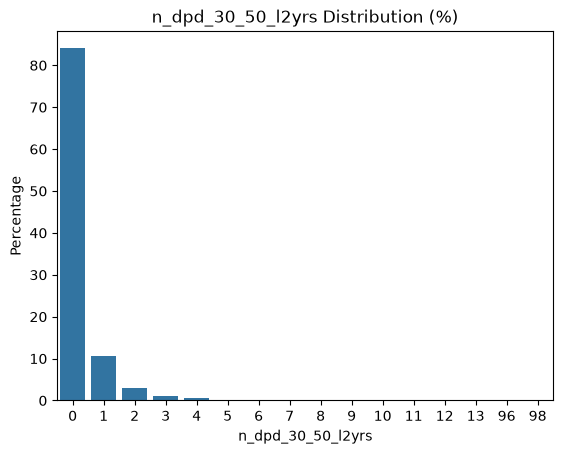

In [34]:
#n_dpd_30_50_l2yrs
uniq_cnts = train_data["n_dpd_30_50_l2yrs"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)
print()
sns.barplot(x=uniq_cnts.index, y=uniq_cnts.values)
plt.ylabel("Percentage")
plt.title("n_dpd_30_50_l2yrs Distribution (%)")
plt.show()

In [35]:
train_data.loc[train_data["n_dpd_90plus_hist"]==98, :].head()

,acct_id,n_dpd_90plus_hist,n_dpd_60_89_l2yrs,n_dpd_30_50_l2yrs,n_mort_loans,n_credit_lines,avg_utli_unsec,debt_income_ratio,age,f_dpd_90plus_nxt_2yrs,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp
1733,id_1734,98,98,98,0,0,1.0,0.0,27,1,0,0,0.0,2700.0
2286,id_2287,98,98,98,0,0,1.0,0.0,22,0,0,1,0.0,5400.0
3884,id_3885,98,98,98,0,0,1.0,12.0,38,0,0,1,0.0,5400.0
4417,id_4418,98,98,98,0,0,1.0,0.0,21,0,0,0,0.0,0.0
4705,id_4706,98,98,98,0,0,1.0,0.0,21,0,0,0,0.0,2000.0


In [36]:
train_data.loc[train_data["n_dpd_90plus_hist"]==96, :].head()

,acct_id,n_dpd_90plus_hist,n_dpd_60_89_l2yrs,n_dpd_30_50_l2yrs,n_mort_loans,n_credit_lines,avg_utli_unsec,debt_income_ratio,age,f_dpd_90plus_nxt_2yrs,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp
41944,id_41945,96,96,96,0,0,1.0,0.000000,26,1,0,1,0.0,5400.0
69478,id_69479,96,96,96,0,0,1.0,0.008047,33,1,0,0,0.0,4100.0
84167,id_84168,96,96,96,0,0,1.0,0.000000,29,1,0,0,2.0,2800.0
94106,id_94107,96,96,96,0,0,1.0,0.000000,34,1,0,0,1.0,3500.0
120049,id_120050,96,96,96,0,0,1.0,0.051765,46,0,0,0,0.0,4616.0


min_n_mort_loans: 0 max_n_mort_loans: 54



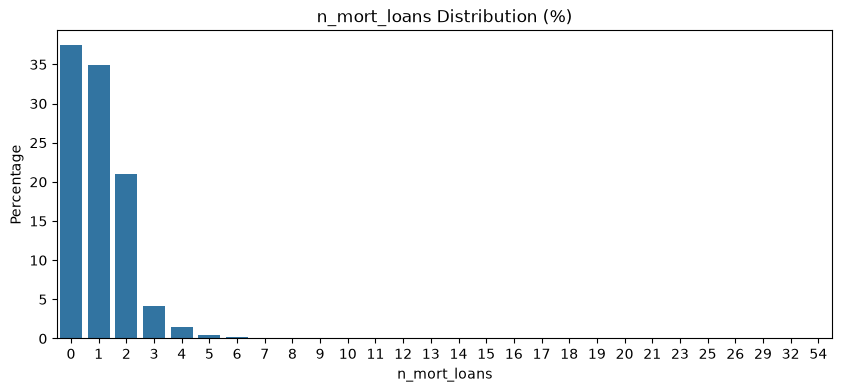

In [37]:
#n_mort_loans
print("min_n_mort_loans:", train_data["n_mort_loans"].min(), "max_n_mort_loans:", train_data["n_mort_loans"].max())
print()
uniq_cnts = train_data["n_mort_loans"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
# print(uniq_cnts)
# print()
plt.figure(figsize=(10, 4))
sns.barplot(x=uniq_cnts.index, y=uniq_cnts.values)
plt.ylabel("Percentage")
plt.title("n_mort_loans Distribution (%)")
plt.show()

min_n_credit_lines: 0 max_n_credit_lines: 58



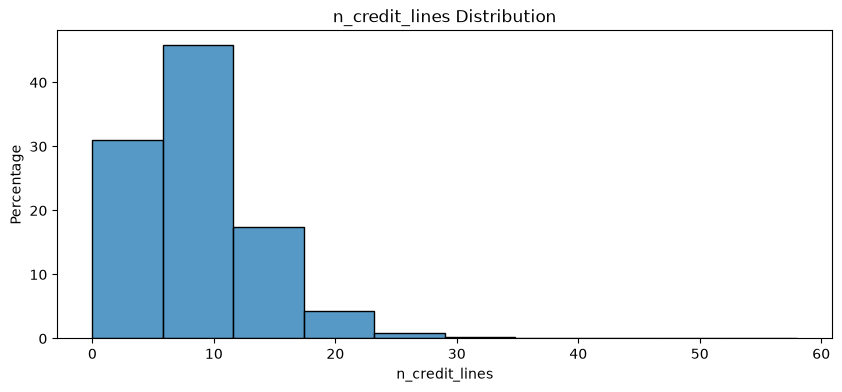

In [38]:
# n_credit_lines
plt.figure(figsize=(10, 4))
print("min_n_credit_lines:", train_data["n_credit_lines"].min(), "max_n_credit_lines:", train_data["n_credit_lines"].max())
print()
sns.histplot(train_data["n_credit_lines"], bins=10, stat="percent")
plt.title("n_credit_lines Distribution")
plt.xlabel("n_credit_lines")
plt.ylabel("Percentage")
plt.show()

min_avg_utli_unsec: 0.0 max_avg_utli_unsec: 50708.0

mean_avg_utli_unsec: 6.048438054666887 median_avg_utli_unsec: 0.154180737



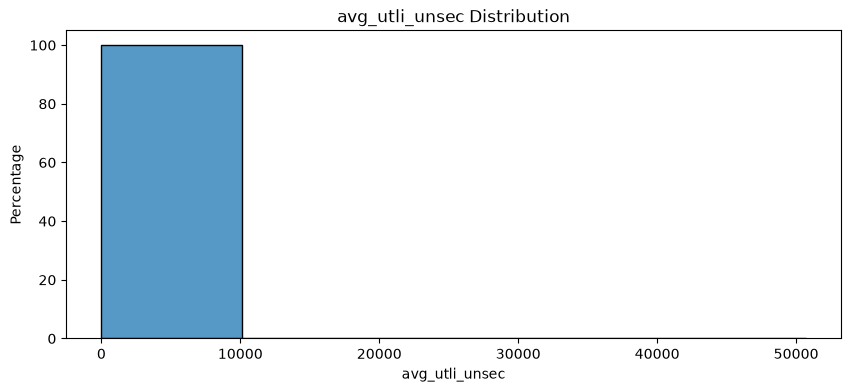

In [39]:
# utilization of unsecured lines
plt.figure(figsize=(10, 4))
print("min_avg_utli_unsec:", train_data["avg_utli_unsec"].min(), "max_avg_utli_unsec:", train_data["avg_utli_unsec"].max())
print()
print("mean_avg_utli_unsec:", train_data["avg_utli_unsec"].mean(), "median_avg_utli_unsec:", train_data["avg_utli_unsec"].median())
print()
sns.histplot(train_data["avg_utli_unsec"], bins=5, stat="percent")
plt.title("avg_utli_unsec Distribution")
plt.xlabel("avg_utli_unsec")
plt.ylabel("Percentage")
plt.show()

<Axes: xlabel='avg_utli_unsec'>

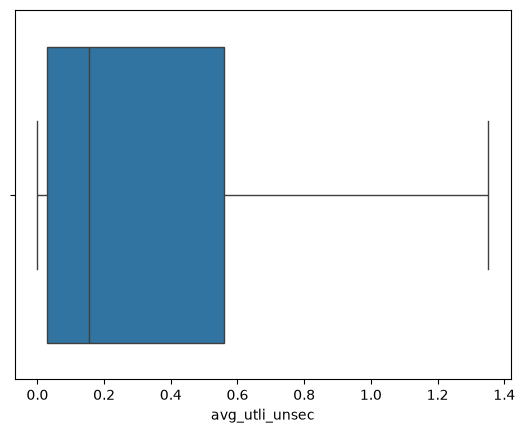

In [40]:
sns.boxplot(x=train_data["avg_utli_unsec"], showfliers=False)

min_debt_income_ratio: 0.0 max_debt_income_ratio: 329664.0

mean_debt_income_ratio: 353.00507576386985 median_debt_income_ratio: 0.366507841



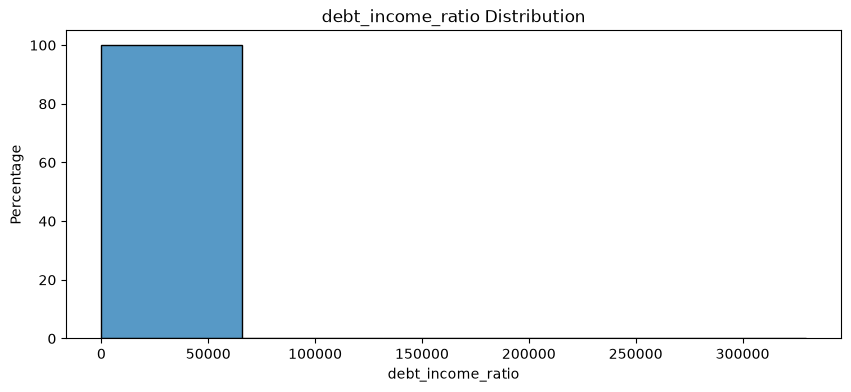

In [41]:
#debt_income_ratio
plt.figure(figsize=(10, 4))
print("min_debt_income_ratio:", train_data["debt_income_ratio"].min(), "max_debt_income_ratio:", train_data["debt_income_ratio"].max())
print()
print("mean_debt_income_ratio:", train_data["debt_income_ratio"].mean(), "median_debt_income_ratio:", train_data["debt_income_ratio"].median())
print()
sns.histplot(train_data["debt_income_ratio"], bins=5, stat="percent")
plt.title("debt_income_ratio Distribution")
plt.xlabel("debt_income_ratio")
plt.ylabel("Percentage")
plt.show()

min_age: 0 max_age: 109

mean_age: 52.295206666666665 median_age: 52.0



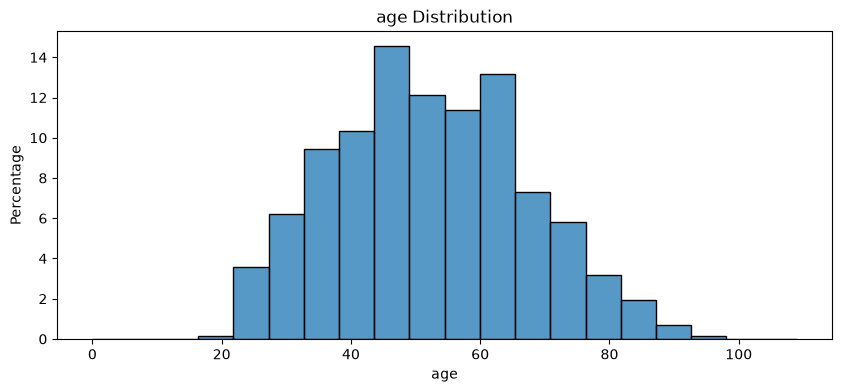

In [42]:
#age
plt.figure(figsize=(10, 4))
print("min_age:", train_data["age"].min(), "max_age:", train_data["age"].max())
print()
print("mean_age:", train_data["age"].mean(), "median_age:", train_data["age"].median())
print()
sns.histplot(train_data["age"], bins=20, stat="percent")
plt.title("age Distribution")
plt.xlabel("age")
plt.ylabel("Percentage")
plt.show()

In [43]:
train_data.columns

Index(['acct_id', 'n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs',
       'n_dpd_30_50_l2yrs', 'n_mort_loans', 'n_credit_lines', 'avg_utli_unsec',
       'debt_income_ratio', 'age', 'f_dpd_90plus_nxt_2yrs',
       'n_dependents_nan_flag', 'monthly_income_nan_flag', 'n_dependents_imp',
       'monthly_income_imp'],
      dtype='str')

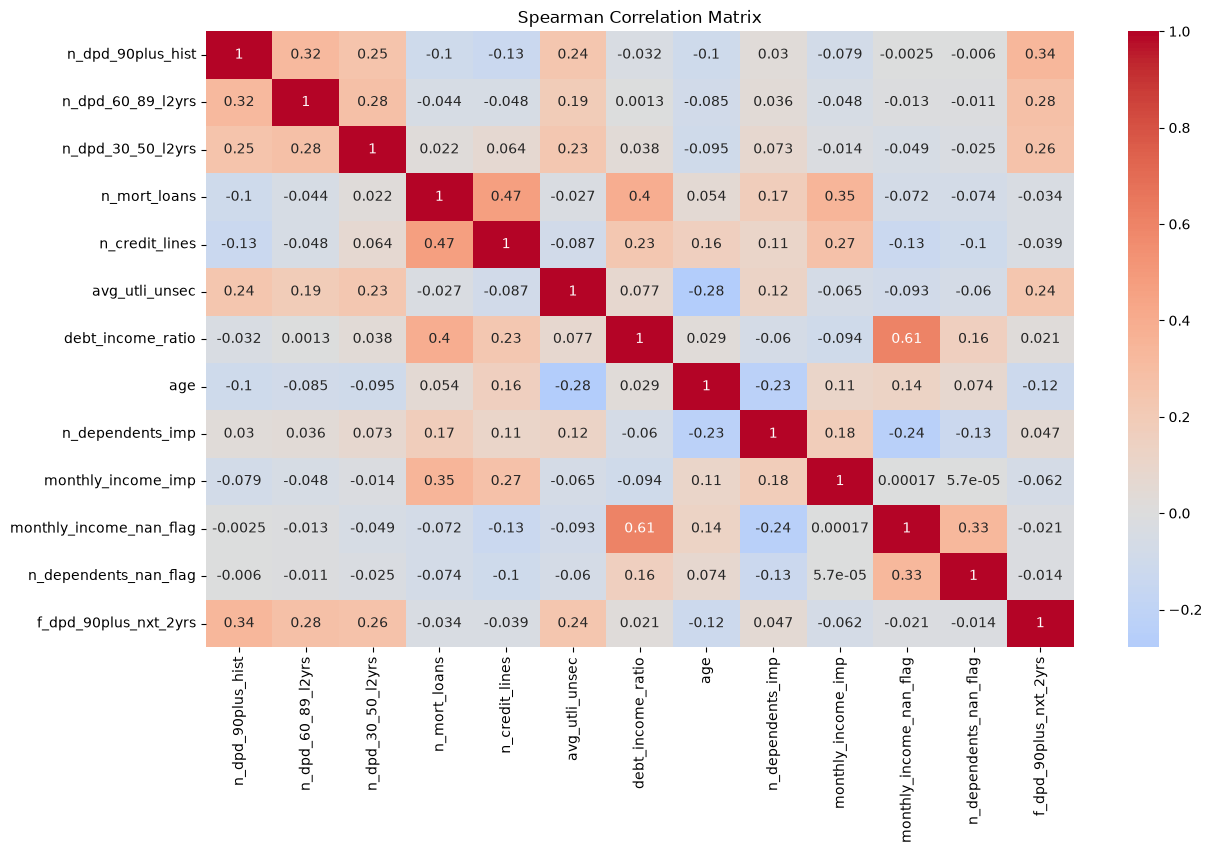

In [44]:
spearman_corr = train_data[
    ['n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs', 'n_dpd_30_50_l2yrs',
     'n_mort_loans', 'n_credit_lines', 'avg_utli_unsec', 'debt_income_ratio',
     'age', 'n_dependents_imp', 'monthly_income_imp', 'monthly_income_nan_flag',
     'n_dependents_nan_flag', 'f_dpd_90plus_nxt_2yrs'
    ]
].corr(method="spearman")

# pearson_corr = train_data[
#     ['n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs', 'n_dpd_30_50_l2yrs',
#      'n_mort_loans', 'n_credit_lines', 'avg_utli_unsec', 'debt_income_ratio',
#      'age', 'n_dependents_imp', 'monthly_income_imp', 'f_dpd_90plus_nxt_2yrs'
#     ]
# ].corr(method="pearson")

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix")
plt.show()

## 3) Bivariate Analysis

In [45]:
train_data.columns

Index(['acct_id', 'n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs',
       'n_dpd_30_50_l2yrs', 'n_mort_loans', 'n_credit_lines', 'avg_utli_unsec',
       'debt_income_ratio', 'age', 'f_dpd_90plus_nxt_2yrs',
       'n_dependents_nan_flag', 'monthly_income_nan_flag', 'n_dependents_imp',
       'monthly_income_imp'],
      dtype='str')

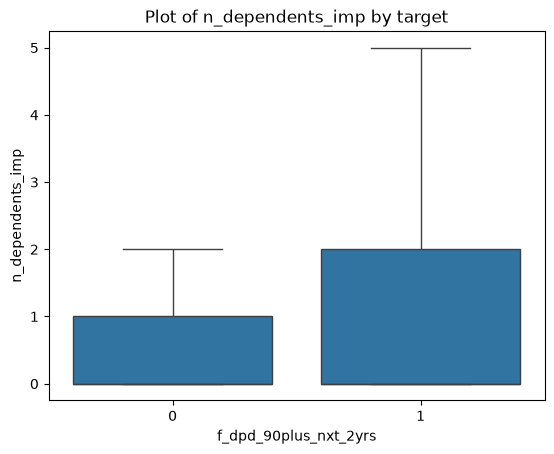

In [46]:
#n_dependents_imp
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_dependents_imp", data=train_data, showfliers=False)
plt.title("Plot of n_dependents_imp by target")
plt.show()

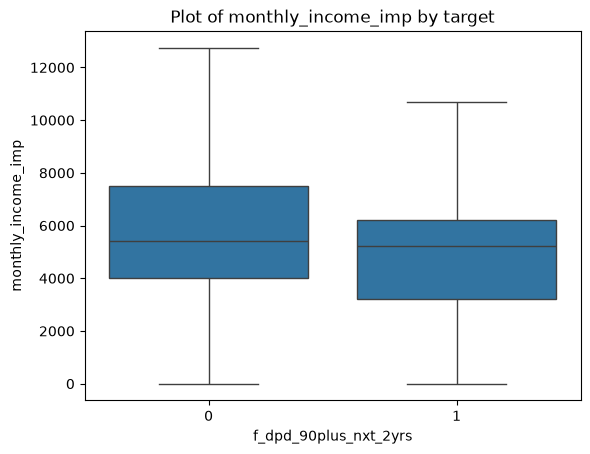

In [47]:
#monthly_income_imp
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="monthly_income_imp", data=train_data, showfliers=False)
plt.title("Plot of monthly_income_imp by target")
plt.show()

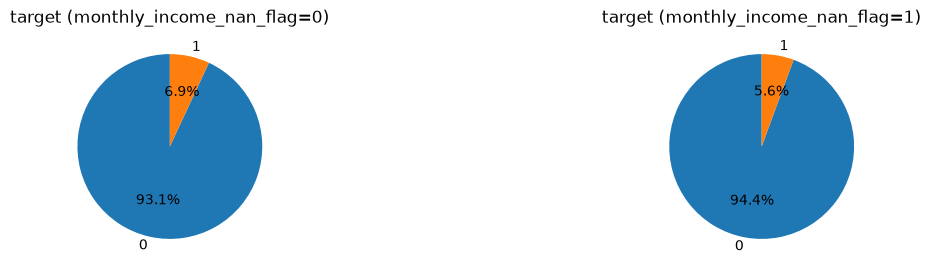

In [48]:
# Split data by monthly_income_nan_flag
df0 = train_data[train_data["monthly_income_nan_flag"] == 0]
df1 = train_data[train_data["monthly_income_nan_flag"] == 1]

# Calculate percentages for each subgroup
pct0 = df0["f_dpd_90plus_nxt_2yrs"].value_counts(normalize=True) * 100
pct1 = df1["f_dpd_90plus_nxt_2yrs"].value_counts(normalize=True) * 100

# Plot side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].pie(pct0.values, labels=pct0.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("target (monthly_income_nan_flag=0)")

axes[1].pie(pct1.values, labels=pct1.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("target (monthly_income_nan_flag=1)")
plt.show()

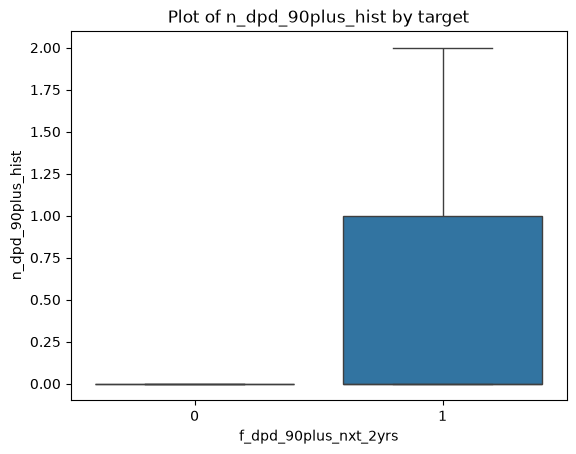

In [49]:
#n_dpd_90plus_hist
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_dpd_90plus_hist", data=train_data, showfliers=False)
plt.title("Plot of n_dpd_90plus_hist by target")
plt.show()

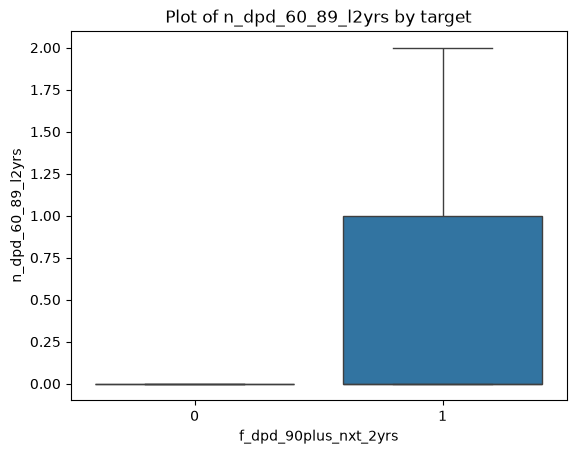

In [50]:
#n_dpd_60_89_l2yrs
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_dpd_60_89_l2yrs", data=train_data, showfliers=False)
plt.title("Plot of n_dpd_60_89_l2yrs by target")
plt.show()

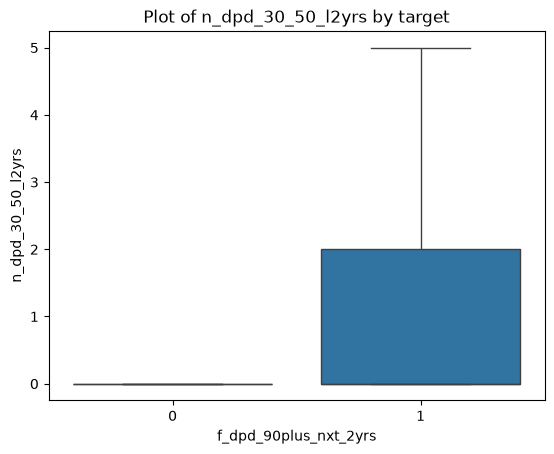

In [52]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_dpd_30_50_l2yrs", data=train_data, showfliers=False)
plt.title("Plot of n_dpd_30_50_l2yrs by target")
plt.show()

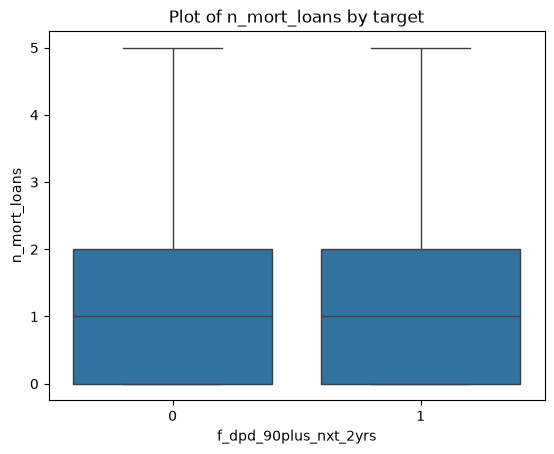

In [51]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_mort_loans", data=train_data, showfliers=False)
plt.title("Plot of n_mort_loans by target")
plt.show()

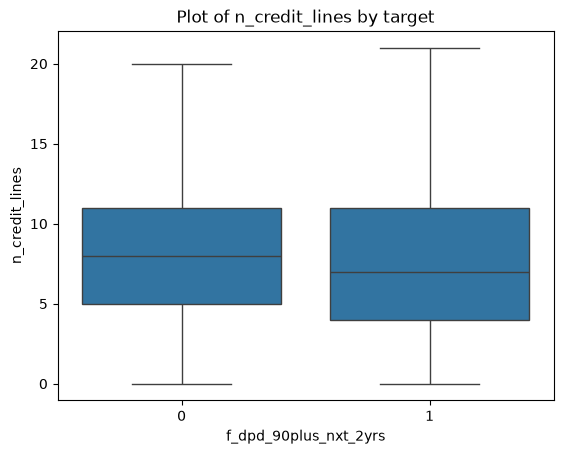

In [53]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="n_credit_lines", data=train_data, showfliers=False)
plt.title("Plot of n_credit_lines by target")
plt.show()

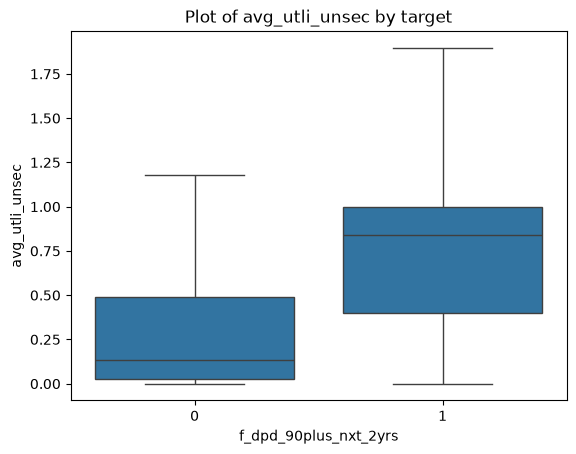

In [54]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="avg_utli_unsec", data=train_data, showfliers=False)
plt.title("Plot of avg_utli_unsec by target")
plt.show()

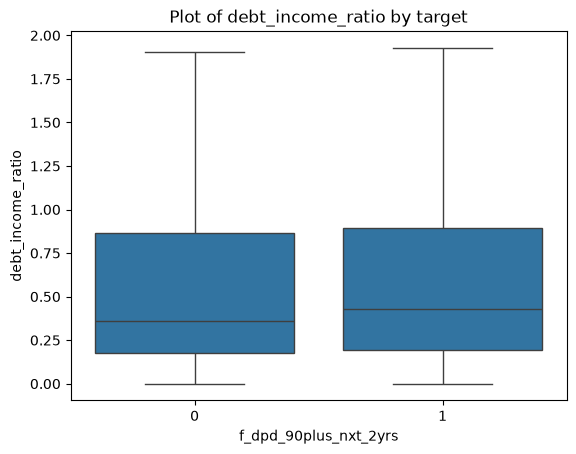

In [55]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="debt_income_ratio", data=train_data, showfliers=False)
plt.title("Plot of debt_income_ratio by target")
plt.show()

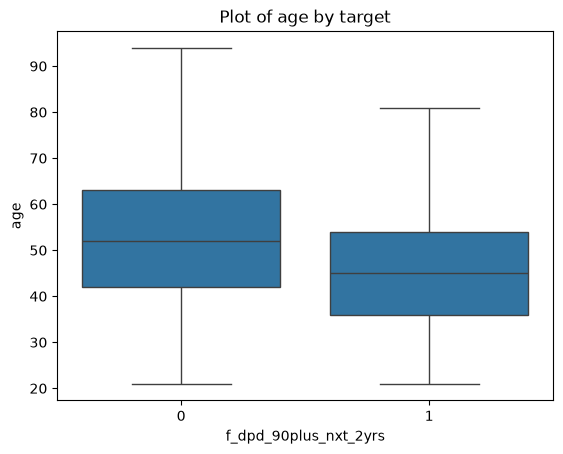

In [56]:
sns.boxplot(x="f_dpd_90plus_nxt_2yrs", y="age", data=train_data, showfliers=False)
plt.title("Plot of age by target")
plt.show()

### 3.1) Handling Outliers for Useful Variables

In [ ]:
# 96, 98 in n_dpd
# 0 in age

In [57]:
uniq_cnts = train_data["n_dpd_90plus_hist"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)

n_dpd_90plus_hist
0     94.441333
1      3.495333
2      1.036667
3      0.444667
4      0.194000
98     0.176000
5      0.087333
6      0.053333
7      0.025333
8      0.014000
9      0.012667
10     0.005333
96     0.003333
11     0.003333
13     0.002667
15     0.001333
14     0.001333
12     0.001333
17     0.000667
Name: proportion, dtype: float64


In [58]:
def impute_invalid_with_median(df, colname, invalid_values=[96, 98]):
    # Compute median excluding invalids
    valid_median = df.loc[~df[colname].isin(invalid_values), colname].median()

    # Create new column with imputation
    new_col = f"{colname}_imp"
    df[new_col] = df[colname].replace(invalid_values, valid_median)

    return df

In [59]:
train_data = impute_invalid_with_median(train_data, "n_dpd_90plus_hist")
train_data = impute_invalid_with_median(train_data, "n_dpd_60_89_l2yrs")
train_data = impute_invalid_with_median(train_data, "n_dpd_30_50_l2yrs")
train_data = impute_invalid_with_median(train_data, "age", [0])

In [60]:
train_data.drop(columns=["n_dpd_90plus_hist", "n_dpd_60_89_l2yrs", "n_dpd_30_50_l2yrs", "age"], inplace=True)

In [61]:
uniq_cnts = train_data["n_dpd_90plus_hist_imp"].value_counts(normalize=True) * 100
uniq_cnts = uniq_cnts.sort_values(ascending=False)
print(uniq_cnts)

n_dpd_90plus_hist_imp
0     94.620667
1      3.495333
2      1.036667
3      0.444667
4      0.194000
5      0.087333
6      0.053333
7      0.025333
8      0.014000
9      0.012667
10     0.005333
11     0.003333
13     0.002667
15     0.001333
14     0.001333
12     0.001333
17     0.000667
Name: proportion, dtype: float64


min_age_imp: 21 max_age: 109

mean_age: 52.29555333333333 median_age: 52.0



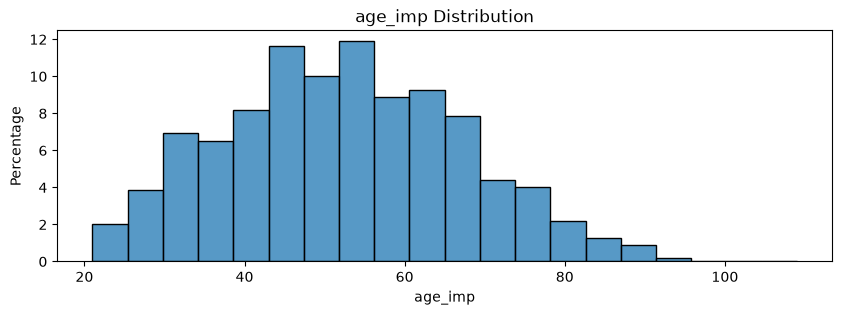

In [ ]:
#age
plt.figure(figsize=(10, 3))
print("min_age_imp:", train_data["age_imp"].min(), "max_age:", train_data["age_imp"].max())
print()
print("mean_age:", train_data["age_imp"].mean(), "median_age:", train_data["age_imp"].median())
print()
sns.histplot(train_data["age_imp"], bins=20, stat="percent") 
plt.title("age_imp Distribution")
plt.xlabel("age_imp")
plt.ylabel("Percentage")
plt.show()

In [63]:
train_data.head()

,acct_id,n_mort_loans,n_credit_lines,avg_utli_unsec,debt_income_ratio,f_dpd_90plus_nxt_2yrs,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
0,id_1,6,13,0.766127,0.802982,1,0,0,2.0,9120.0,0,0,2,45
1,id_2,0,4,0.957151,0.121876,0,0,0,1.0,2600.0,0,0,0,40
2,id_3,0,2,0.658180,0.085113,0,0,0,0.0,3042.0,1,0,1,38
3,id_4,0,5,0.233810,0.036050,0,0,0,0.0,3300.0,0,0,0,30
4,id_5,1,7,0.907239,0.024926,0,0,0,0.0,63588.0,0,0,1,49


## 4) Model Fitting and Model Specific Preprocessing

### 4.1) Logistic Regression

#### 4.1.1) Binning & IV, WOE Computation

In [ ]:
# Useful variables: 'n_dpd_90plus_hist', 'n_dpd_60_89_l2yrs', 'n_dpd_30_50_l2yrs', 'avg_utli_unsec', 'age'
# Weak variables: 'n_dependents_imp', 'monthly_income_imp'
# Useless variables: 'n_mort_loans', 'n_credit_lines', 'debt_income_ratio', 'monthly_income_nan_flag'

In [ ]:
# def compute_iv(var_name):
#     if var_name in ("avg_utli_unsec", "age_imp", "monthly_income_imp", "debt_income_ratio"):
#         dtype = "numerical"
#         var_type = "continuous"
#     else:
#         dtype = "numerical"
#         var_type = "ordinal"

#     binning = OptimalBinning(name=var_name, dtype=dtype)
#     binning.fit(train_data[var_name], train_data["f_dpd_90plus_nxt_2yrs"])
#     binning_table = binning.binning_table.build()
#     iv = binning_table["IV"].iloc[-1]
#     return iv, var_type

In [ ]:
# variables = [
#     'n_dpd_90plus_hist_imp', 'n_dpd_60_89_l2yrs_imp', 'n_dpd_30_50_l2yrs_imp',
#     'avg_utli_unsec', 'age_imp', 'n_dependents_imp', 'monthly_income_imp',
#     'n_mort_loans', 'n_credit_lines', 'debt_income_ratio', 'monthly_income_nan_flag'
# ]

# iv_results = []
# for var in variables:
#     iv, var_type = compute_iv(var)
#     iv_results.append((var, var_type, iv))

# iv_df = pd.DataFrame(iv_results, columns=["var_name", "var_type", "iv"])
# iv_df

NameError: name 'OptimalBinning' is not defined

In [ ]:
# def calc_woe_trend(var_name):
#     if var_name in ("avg_utli_unsec", "age_imp", "monthly_income_imp", "debt_income_ratio"):
#         dtype = "numerical"
#         var_type = "continuous"
#     else:
#         dtype = "numerical"
#         var_type = "ordinal"

#     binning = OptimalBinning(
#         name=var_name,
#         dtype=dtype
#     )

#     binning.fit(train_data[var_name], train_data["f_dpd_90plus_nxt_2yrs"])
#     binning_table = binning.binning_table.build()
#     binning_table.insert(0, "variable", var_name)
#     return binning_table[["variable", "Bin", "WoE"]]

In [ ]:
# def plot_woe_trend(input_df):
#     plot_df =  input_df.iloc[:-1]
#     plot_title =  plot_df.at[0, "variable"]

#     plt.figure(figsize=(10, 2))
#     plt.plot(plot_df["Bin"], plot_df["WoE"], marker="o")
#     plt.title(plot_title)
#     plt.xlabel("Bin")
#     plt.ylabel("WoE")
#     plt.xticks(rotation=45)
#     plt.grid(True)
#     plt.show()

In [ ]:
# #Below are the only useful variables

# plot_woe_trend(
#     input_df = calc_woe_trend("n_dpd_90plus_hist_imp")
# )
# plot_woe_trend(
#     input_df = calc_woe_trend("n_dpd_30_50_l2yrs_imp")
# )
# plot_woe_trend(
#     input_df = calc_woe_trend("avg_utli_unsec")
# )
# plot_woe_trend(
#     input_df = calc_woe_trend("age_imp")
# )
# plot_woe_trend(
#     input_df = calc_woe_trend("monthly_income_imp")
# )
# # plot_woe_trend(
# #     input_df = calc_woe_trend("n_credit_lines")
# # )
# plot_woe_trend(
#     input_df = calc_woe_trend("debt_income_ratio")
# )

In [ ]:
# impn_vars_logit = [
#     "n_dpd_90plus_hist_imp",
#     "n_dpd_30_50_l2yrs_imp",
#     "avg_utli_unsec",
#     "age_imp",
#     "monthly_income_imp",
#     "debt_income_ratio"
# ]

# iv_df.loc[iv_df["var_name"].isin(impn_vars_logit), :]

In [ ]:
# train_logit_data = train_data.loc[:, ["acct_id"] + impn_vars_logit + ["f_dpd_90plus_nxt_2yrs"]].copy(deep=True)

In [ ]:
# train_logit_data.head(3)

In [ ]:
# def woe_transformation(var_list, target="f_dpd_90plus_nxt_2yrs", train_data=train_logit_data):
#     for var_name in var_list:
#         binning = OptimalBinning(name=var_name, dtype="numerical")
#         binning.fit(train_data[var_name], train_data[target])
#         woe_trans_series = binning.transform(train_data[var_name], metric="woe")
#         train_data[f"{var_name}_woe"] = woe_trans_series

#     return train_data

In [ ]:
# train_raw_woetrns_data = woe_transformation(
#     var_list = impn_vars_logit
# )

# train_logit_woetrns_data = train_raw_woetrns_data.drop(
#     columns=impn_vars_logit
# )

# train_logit_woetrns_data.head(3)

In [ ]:
# train_df, test_df = train_test_split(
#     train_logit_woetrns_data,
#     test_size=0.2,
#     random_state=0,
#     shuffle=True
# )

# print("Train shape:", train_df.shape)
# print("Test shape:", test_df.shape)

In [ ]:
# X_train = train_df.loc[:, ['avg_utli_unsec_woe', 'n_dpd_90plus_hist_imp_woe', 'n_dpd_30_50_l2yrs_imp_woe', 'age_imp_woe', 'monthly_income_imp_woe', 'debt_income_ratio_woe']].copy()
# y_train = train_df.loc[:, ["f_dpd_90plus_nxt_2yrs"]].copy()

# X_test = test_df.loc[:, ['avg_utli_unsec_woe', 'n_dpd_90plus_hist_imp_woe', 'n_dpd_30_50_l2yrs_imp_woe', 'age_imp_woe', 'monthly_income_imp_woe', 'debt_income_ratio_woe']].copy()
# y_test = test_df.loc[:, ["f_dpd_90plus_nxt_2yrs"]].copy()

# print(X_train.shape, y_train.shape)
# print(X_test.shape, y_test.shape)

#### 4.1.2) Model Fitting

In [ ]:
# X_train.head(3)

In [ ]:
# y_train.head(3)

In [ ]:
# def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
#     vif_data = pd.DataFrame()
#     vif_data["feature"] = X.columns
#     vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
#     return vif_data

In [ ]:
# compute_vif(X_train)

In [ ]:
# def backward_elimination(
#     X: pd.DataFrame,
#     y: pd.Series,
#     significance_level: float = 0.05,
#     vif_threshold: float = 5
# ):
#     """
#     Perform backward elimination with mandatory VIF check and Gini tracking.
#     """
#     X = sm.add_constant(X, has_constant="add")
#     variables = list(X.columns)

#     while True:
#         # Fit logistic regression with current variables
#         model = sm.Logit(y, X[variables]).fit(disp=0)
#         y_pred = model.predict(X[variables])
#         auc = roc_auc_score(y, y_pred)
#         gini = 2 * auc - 1
#         print(f"\nCurrent variables: {variables}")
#         print(f"Gini: {gini:.4f}")

#         # Compute VIF excluding constant
#         vif = compute_vif(X[variables].drop(columns="const", errors="ignore"))
#         print("VIF values:")
#         print(vif)

#         # Print p-values
#         print("P-values:")
#         print(model.pvalues)

#         # Step 1: Drop variable with highest VIF if > threshold
#         max_vif = vif["VIF"].max()
#         if max_vif > vif_threshold:
#             excluded_var = vif.loc[vif["VIF"].idxmax(), "feature"]
#             variables.remove(excluded_var)
#             print(f"Removing {excluded_var} due to high VIF ({max_vif:.2f})\n")
#             continue

#         # Step 2: Drop variable with highest p-value if > significance_level
#         p_values = model.pvalues.drop("const", errors="ignore")
#         max_pval = p_values.max()
#         if max_pval > significance_level:
#             excluded_var = p_values.idxmax()
#             variables.remove(excluded_var)
#             print(f"Removing {excluded_var} with p-value {max_pval:.4f}\n")
#         else:
#             break

#     return model

In [ ]:
# bkwelm_best_model = backward_elimination(X_train, y_train)

In [ ]:
# bkwelm_best_model.summary()

#### 4.1.3) Model Evaluation on Test Data

In [ ]:
# X_test.head(3)

In [ ]:
# # Predict probabilities on test set
# X_test_const = sm.add_constant(X_test)
# y_test_pred = bkwelm_best_model.predict(X_test_const)

# auc = roc_auc_score(y_test, y_test_pred)
# gini = 2 * auc - 1
# print(100 * gini)

In [ ]:
# y_test = pd.Series(y_test["f_dpd_90plus_nxt_2yrs"])
# y_test = y_test.reset_index(drop=True)
# y_test_pred = y_test_pred.reset_index(drop=True)

In [ ]:
# def plot_cap(y_true, y_pred, title):
#     total = len(y_true)
#     class_1_count = np.sum(y_true)

#     sorted_indices = np.argsort(y_pred)[::-1]
#     y_true_sorted = y_true[sorted_indices]

#     cum_pos = np.cumsum(y_true_sorted)

#     x_values = np.arange(1, total+1) / total
#     y_values = cum_pos / class_1_count

#     plt.plot([0,1], [0,1], linestyle='--', color='grey', label="Random Model")
#     plt.plot([0, class_1_count/total, 1], [0,1,1], linestyle='--', color='green', label="Perfect Model")

#     # Your model CAP curve
#     plt.plot(x_values, y_values, color='blue', label="Model")

#     plt.title(title)
#     plt.xlabel("Proportion of data (sorted by score)")
#     plt.ylabel("Proportion of positives captured")
#     plt.legend()
#     plt.grid(True)
#     plt.show()

In [ ]:
# plot_cap(
#     y_test,
#     y_test_pred,
#     title = "CAP Curve - Logistic Regression Model"
# )

#### 4.1.4) Model Fitting without WOE Transformation

In [ ]:
# impn_vars_logit

In [ ]:
# train_logit_data = train_data.loc[:, ["acct_id"] + impn_vars_logit + ["f_dpd_90plus_nxt_2yrs"]].copy(deep=True)

In [ ]:
# train_logit_data.columns

In [ ]:
# train_df, test_df = train_test_split(
#     train_logit_data,
#     test_size=0.2,
#     random_state=0,
#     shuffle=True
# )

# train_df = train_df.reset_index(drop=True)
# test_df = test_df.reset_index(drop=True)

# print("Train shape:", train_df.shape)
# print("Test shape:", test_df.shape)

In [ ]:
# X_train = train_df.loc[:, ['avg_utli_unsec', 'n_dpd_90plus_hist_imp', 'n_dpd_30_50_l2yrs_imp', 'age_imp', 'monthly_income_imp', 'debt_income_ratio']].copy()
# y_train = train_df.loc[:, ["f_dpd_90plus_nxt_2yrs"]].copy()
# y_train = pd.Series(y_train["f_dpd_90plus_nxt_2yrs"])

# X_test = test_df.loc[:, ['avg_utli_unsec', 'n_dpd_90plus_hist_imp', 'n_dpd_30_50_l2yrs_imp', 'age_imp', 'monthly_income_imp', 'debt_income_ratio']].copy()
# y_test = test_df.loc[:, ["f_dpd_90plus_nxt_2yrs"]].copy()
# y_test = pd.Series(y_test["f_dpd_90plus_nxt_2yrs"])

# print(X_train.shape, y_train.shape)
# print(X_test.shape, y_test.shape)

In [ ]:
# X_train.head(3)

In [ ]:
# X_test.head(3)

In [ ]:
# scaler = StandardScaler()

# X_train = pd.DataFrame(
#     scaler.fit_transform(X_train),
#     columns=X_train.columns
# )

# X_test = pd.DataFrame(
#     scaler.fit_transform(X_test),
#     columns=X_test.columns
# )

In [ ]:
# X_train.head(3)

In [ ]:
# X_test.head(3)

In [ ]:
# def backward_elimination(
#     X: pd.DataFrame,
#     y: pd.Series,
#     significance_level: float = 0.05,
#     vif_threshold: float = 5
# ):
#     """
#     Perform backward elimination with mandatory VIF check and Gini tracking.
#     """
#     X = sm.add_constant(X, has_constant="add")
#     variables = list(X.columns)

#     while True:
#         # Fit logistic regression with current variables
#         model = sm.Logit(y, X[variables]).fit(disp=0)
#         y_pred = model.predict(X[variables])
#         auc = roc_auc_score(y, y_pred)
#         gini = 2 * auc - 1
#         print(f"\nCurrent variables: {variables}")
#         print(f"Gini: {gini:.4f}")

#         # Compute VIF excluding constant
#         vif = compute_vif(X[variables].drop(columns="const", errors="ignore"))
#         print("VIF values:")
#         print(vif)

#         # Print p-values
#         print("P-values:")
#         print(model.pvalues)

#         # Step 1: Drop variable with highest VIF if > threshold
#         max_vif = vif["VIF"].max()
#         if max_vif > vif_threshold:
#             excluded_var = vif.loc[vif["VIF"].idxmax(), "feature"]
#             variables.remove(excluded_var)
#             print(f"Removing {excluded_var} due to high VIF ({max_vif:.2f})\n")
#             continue

#         # Step 2: Drop variable with highest p-value if > significance_level
#         p_values = model.pvalues.drop("const", errors="ignore")
#         max_pval = p_values.max()
#         if max_pval > significance_level:
#             excluded_var = p_values.idxmax()
#             variables.remove(excluded_var)
#             print(f"Removing {excluded_var} with p-value {max_pval:.4f}\n")
#         else:
#             break

#     return model

In [ ]:
# bkwelm_best_model_1 = backward_elimination(X_train, y_train)

In [ ]:
# bkwelm_best_model_1.summary()

In [ ]:
# X_train_2 = X_train.drop(["debt_income_ratio"], axis=1)
# X_test_2 = X_test.drop(["debt_income_ratio"], axis=1)

In [ ]:
# print(X_train_2.head(2))
# print()
# print(X_test_2.head(2))

In [ ]:
# bkwelm_best_model_1 = backward_elimination(X_train_2, y_train)

In [ ]:
# bkwelm_best_model_1.summary()

In [ ]:
# X_train_3 = X_train.drop(["monthly_income_imp"], axis=1)
# X_test_3 = X_test.drop(["monthly_income_imp"], axis=1)

# print(X_train_3.head(2))
# print()
# print(X_test_3.head(2))

In [ ]:
# bkwelm_best_model_3 = backward_elimination(X_train_3, y_train)

#### 4.1.5) Model Evaluation on Test Data

In [ ]:
# X_test.head(3)

### 4.2) Decision Tree

In [ ]:
variables = [
    'n_dpd_90plus_hist_imp', 'n_dpd_30_50_l2yrs_imp', 'avg_utli_unsec',
    'age_imp', 'n_dependents_imp', 'monthly_income_imp', 'n_mort_loans',
    'n_credit_lines', 'debt_income_ratio'
]

impn_vars_logit = [
    "n_dpd_90plus_hist_imp",
    "n_dpd_30_50_l2yrs_imp",
    "avg_utli_unsec",
    "age_imp",
    "monthly_income_imp",
    "debt_income_ratio"
]

In [ ]:
train_data.head(3)

,acct_id,n_mort_loans,n_credit_lines,avg_utli_unsec,debt_income_ratio,f_dpd_90plus_nxt_2yrs,n_dependents_nan_flag,monthly_income_nan_flag,n_dependents_imp,monthly_income_imp,n_dpd_90plus_hist_imp,n_dpd_60_89_l2yrs_imp,n_dpd_30_50_l2yrs_imp,age_imp
0,id_1,6,13,0.766127,0.802982,1,0,0,2.0,9120.0,0,0,2,45
1,id_2,0,4,0.957151,0.121876,0,0,0,1.0,2600.0,0,0,0,40
2,id_3,0,2,0.658180,0.085113,0,0,0,0.0,3042.0,1,0,1,38


In [ ]:
train_logit_data = train_data.loc[:, ["acct_id"] + impn_vars_logit + ["f_dpd_90plus_nxt_2yrs"]].copy(deep=True)

In [ ]:
train_logit_data.head(3)

,acct_id,n_dpd_90plus_hist_imp,n_dpd_30_50_l2yrs_imp,avg_utli_unsec,age_imp,monthly_income_imp,debt_income_ratio,f_dpd_90plus_nxt_2yrs
0,id_1,0,2,0.766127,45,9120.0,0.802982,1
1,id_2,0,0,0.957151,40,2600.0,0.121876,0
2,id_3,1,1,0.658180,38,3042.0,0.085113,0


In [ ]:
train_df, test_df = train_test_split(
    train_logit_data,
    test_size=0.2,
    random_state=0,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (120000, 8)
Test shape: (30000, 8)


In [ ]:
X_train = train_df.loc[:, ['avg_utli_unsec', 'n_dpd_90plus_hist_imp', 'n_dpd_30_50_l2yrs_imp', 'age_imp', 'monthly_income_imp', 'debt_income_ratio']].copy()
y_train = train_df.loc[:, ["f_dpd_90plus_nxt_2yrs"]].copy()
y_train = pd.Series(y_train["f_dpd_90plus_nxt_2yrs"])

X_test = test_df.loc[:, ['avg_utli_unsec', 'n_dpd_90plus_hist_imp', 'n_dpd_30_50_l2yrs_imp', 'age_imp', 'monthly_income_imp', 'debt_income_ratio']].copy()
y_test = test_df.loc[:, ["f_dpd_90plus_nxt_2yrs"]].copy()
y_test = pd.Series(y_test["f_dpd_90plus_nxt_2yrs"])

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(120000, 6) (120000,)
(30000, 6) (30000,)


In [ ]:
dt = DecisionTreeClassifier(
    random_state=0
)

param_dist = {
    "max_depth": randint(3, 20),
    "min_samples_split": randint(50, 1000),
    "min_samples_leaf": randint(20, 500)
}

# Randomized Search
random_search = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)

best_dt = random_search.best_estimator_
best_dt.fit(X_train, y_train)

#Check Model Fit
y_train_prob = best_dt.predict_proba(X_train)[:,1]
auc_train = roc_auc_score(y_train, y_train_prob)
gini_train = 2 * auc_train - 1
print("Test ROC AUC:", gini_train)

# Evaluate
y_test_prob = best_dt.predict_proba(X_test)[:,1]
auc_test = roc_auc_score(y_test, y_test_prob)
gini_test = 2 * auc_test - 1
print("Test ROC AUC:", gini_test)

Best parameters: {'max_depth': 9, 'min_samples_leaf': 455, 'min_samples_split': 910}
Test ROC AUC: 0.7168238244237346
Test ROC AUC: 0.6753470660164058


In [ ]:
# Plot the tree
# plt.figure(figsize=(20, 10))
# plot_tree(
#     best_dt,
#     feature_names=X_train.columns,
#     class_names=["No Default", "Default"],
#     filled=True,
#     rounded=True,
#     fontsize=10
# )
# plt.show()

                 Feature  Importance
1  n_dpd_90plus_hist_imp    0.609268
0         avg_utli_unsec    0.206900
2  n_dpd_30_50_l2yrs_imp    0.135906
5      debt_income_ratio    0.028654
3                age_imp    0.012546
4     monthly_income_imp    0.006726


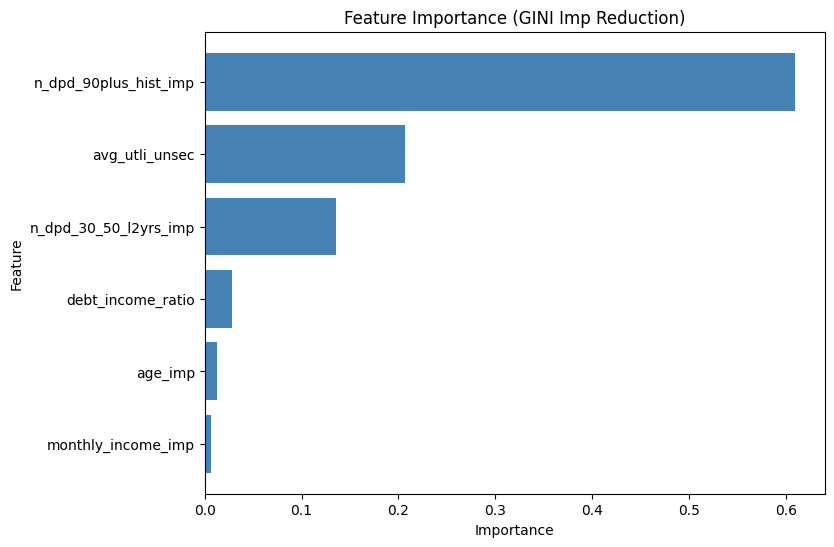

In [ ]:
importances = best_dt.feature_importances_

feat_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
    }).sort_values(
        by="Importance",
        ascending=False
    )

print(feat_importance_df)

# Plot horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(
    feat_importance_df["Feature"],
    feat_importance_df["Importance"],
    color="steelblue"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (GINI Imp Reduction)")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

                 Feature  Mean |SHAP| (class=1)
0         avg_utli_unsec               0.034715
1  n_dpd_90plus_hist_imp               0.031783
2  n_dpd_30_50_l2yrs_imp               0.024679
5      debt_income_ratio               0.008115
3                age_imp               0.006425
4     monthly_income_imp               0.002191



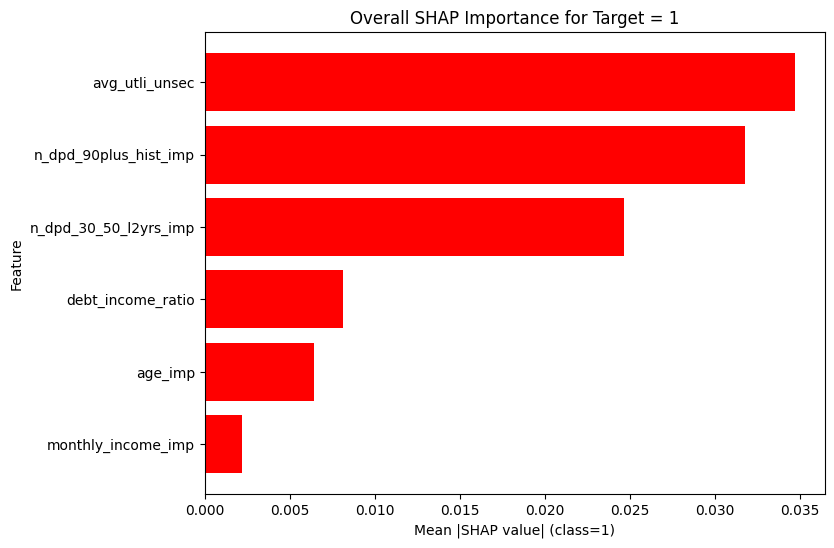

In [ ]:
explainer = shap.Explainer(best_dt)
shap_values = explainer(X_train)
shap_class1 = shap_values.values[:, :, 1]

feat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Mean |SHAP| (class=1)": np.abs(shap_class1).mean(axis=0)
})

feat_importance = feat_importance.sort_values(
    by="Mean |SHAP| (class=1)",
    ascending=False
)

print(feat_importance)
print()
# 5. Plot horizontal bar chart
plt.figure(figsize=(8,6))
plt.barh(feat_importance["Feature"], feat_importance["Mean |SHAP| (class=1)"], color="red")
plt.xlabel("Mean |SHAP value| (class=1)")
plt.ylabel("Feature")
plt.title("Overall SHAP Importance for Target = 1")
plt.gca().invert_yaxis()
plt.show()

                 Feature  Mean |SHAP| (class=1)
0         avg_utli_unsec               0.034630
1  n_dpd_90plus_hist_imp               0.031873
2  n_dpd_30_50_l2yrs_imp               0.024343
5      debt_income_ratio               0.008102
3                age_imp               0.006463
4     monthly_income_imp               0.002184



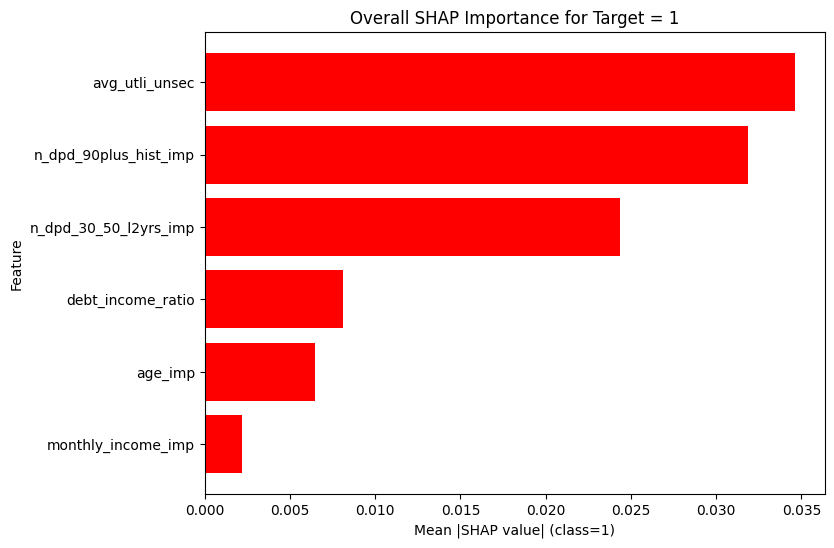

In [ ]:
explainer = shap.Explainer(best_dt)
shap_values = explainer(X_test)
shap_class1 = shap_values.values[:, :, 1]

feat_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean |SHAP| (class=1)": np.abs(shap_class1).mean(axis=0)
})

feat_importance = feat_importance.sort_values(
    by="Mean |SHAP| (class=1)",
    ascending=False
)

print(feat_importance)
print()
# 5. Plot horizontal bar chart
plt.figure(figsize=(8,6))
plt.barh(feat_importance["Feature"], feat_importance["Mean |SHAP| (class=1)"], color="red")
plt.xlabel("Mean |SHAP value| (class=1)")
plt.ylabel("Feature")
plt.title("Overall SHAP Importance for Target = 1")
plt.gca().invert_yaxis()
plt.show()

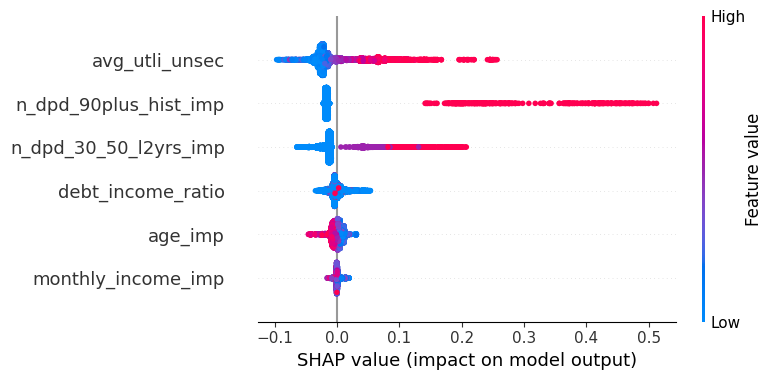

In [ ]:
X_subset = X_train.iloc[:10000, :]
shap_values = explainer(X_subset)

# 3. Extract SHAP values for target class = 1
shap_class1 = shap_values.values[:, :, 1]

# 4. Plot dotted summary chart (distribution of SHAP values)
shap.summary_plot(
    shap_class1,
    X_subset,
    plot_type="dot"
)

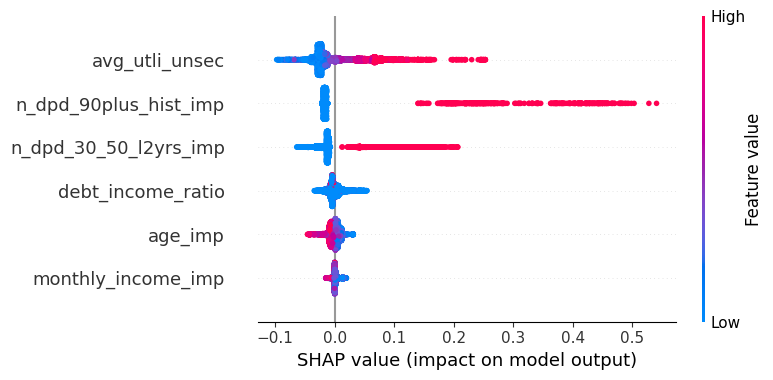

In [ ]:
X_subset = X_test.iloc[:10000, :]
shap_values = explainer(X_subset)

# 3. Extract SHAP values for target class = 1
shap_class1 = shap_values.values[:, :, 1]

# 4. Plot dotted summary chart (distribution of SHAP values)
shap.summary_plot(
    shap_class1,
    X_subset,
    plot_type="dot"
)

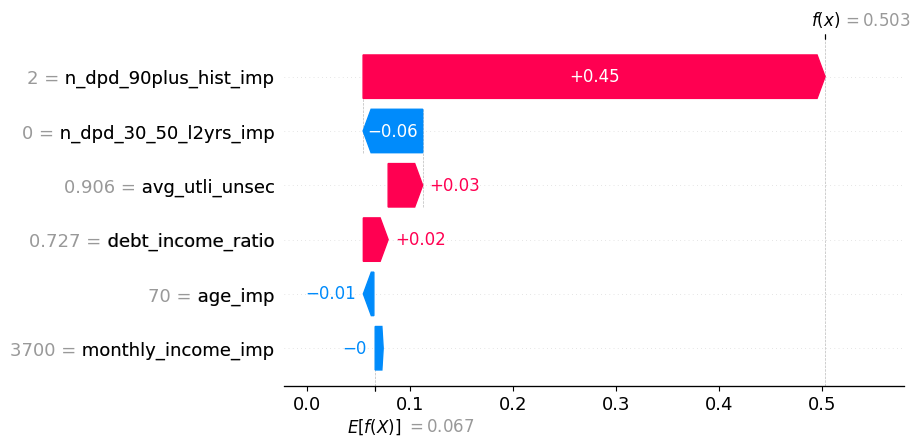

In [ ]:
# Pick one observation
row_index = 30
X_row = X_train.iloc[[row_index]]

# Compute SHAP values for this observation
shap_values = explainer(X_row)

# Extract SHAP values for target class = 1
shap_class1_row = shap_values.values[0, :, 1]

# Plot waterfall chart
shap.plots.waterfall(shap.Explanation(
    values=shap_class1_row,
    base_values=shap_values.base_values[0, 1],
    data=X_row.values[0],
    feature_names=X_train.columns
))

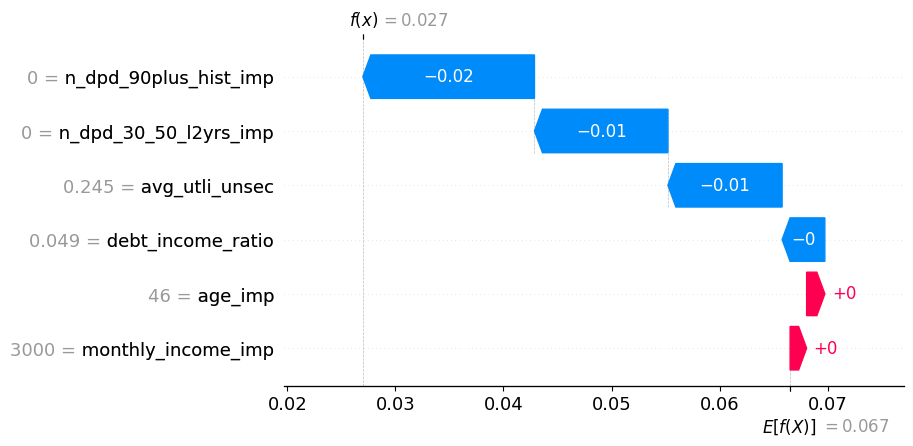

In [ ]:
# Pick one observation
row_index = 5
X_row = X_train.iloc[[row_index]]

# Compute SHAP values for this observation
shap_values = explainer(X_row)

# Extract SHAP values for target class = 1
shap_class1_row = shap_values.values[0, :, 1]

# Plot waterfall chart
shap.plots.waterfall(shap.Explanation(
    values=shap_class1_row,
    base_values=shap_values.base_values[0, 1],
    data=X_row.values[0],
    feature_names=X_train.columns
))

### 4.3) Ensemble Model 1 - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(
    random_state=0,
    n_estimators = 10,
    n_jobs=-1
)

In [ ]:
param_dist = {
    "max_depth": [3, 5, 8, 12, 16, 20, None],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "min_samples_split": [2, 5, 10, 20, 50]
}

In [ ]:
grid_search = GridSearchCV(
    rf,
    param_dist,
    scoring="roc_auc",
    cv=5
)

In [ ]:
#Tune max_depth, min_samples_leaf & min_samples_split - for basic tree structure

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_rf_temp_1 = grid_search.best_estimator_
best_rf_temp_1.fit(X_train, y_train)

#Check Model Fit
y_train_prob = best_rf_temp_1.predict_proba(X_train)[:,1]
auc_train = roc_auc_score(y_train, y_train_prob)
gini_train = 2 * auc_train - 1
print("Train ROC AUC:", gini_train)

# Evaluate
y_test_prob = best_rf_temp_1.predict_proba(X_test)[:,1]
auc_test = roc_auc_score(y_test, y_test_prob)
gini_test = 2 * auc_test - 1
print("Test ROC AUC:", gini_test)

Best parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}
Test ROC AUC: 0.7299181397515881
Test ROC AUC: 0.6886049271772534


In [ ]:
#Tune max_features - for true diversification
best_rf_temp_1 = RandomForestClassifier(
    n_estimators = 10,
    max_depth = 8,
    min_samples_leaf = 5,
    min_samples_split = 2,
    random_state=0,
    n_jobs=-1
)

param_dist = {
    "max_features": ["sqrt", "log2", 0.2, 0.4, 0.6, 0.8]
}

grid_search = GridSearchCV(
    best_rf_temp_1,
    param_dist,
    scoring="roc_auc",
    cv=5
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

best_rf_temp_2 = grid_search.best_estimator_
best_rf_temp_2.fit(X_train, y_train)

#Check Model Fit
y_train_prob = best_rf_temp_2.predict_proba(X_train)[:,1]
auc_train = roc_auc_score(y_train, y_train_prob)
gini_train = 2 * auc_train - 1
print("Train ROC AUC:", gini_train)

# Evaluate
y_test_prob = best_rf_temp_2.predict_proba(X_test)[:,1]
auc_test = roc_auc_score(y_test, y_test_prob)
gini_test = 2 * auc_test - 1
print("Test ROC AUC:", gini_test)

Best parameters: {'max_features': 'sqrt'}
Test ROC AUC: 0.7299181397515881
Test ROC AUC: 0.6886049271772534


In [ ]:
#Tune n_estimators - for variance reduction

best_rf_temp_2 = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 8,
    min_samples_leaf = 5,
    min_samples_split = 2,
    max_features = "sqrt",
    random_state=0,
    n_jobs=-1
)

best_rf_temp_2.fit(X_train, y_train)

#Check Model Fit
y_train_prob = best_rf_temp_2.predict_proba(X_train)[:,1]
auc_train = roc_auc_score(y_train, y_train_prob)
gini_train = 2 * auc_train - 1
print("Train ROC AUC:", gini_train)

# Evaluate
y_test_prob = best_rf_temp_2.predict_proba(X_test)[:,1]
auc_test = roc_auc_score(y_test, y_test_prob)
gini_test = 2 * auc_test - 1
print("Test ROC AUC:", gini_test)

Test ROC AUC: 0.7361050518594281
Test ROC AUC: 0.6918848400691426
